# Matplotlib Formatting Charts

Load the data.

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\KAIF FIROZ\anaconda3\envs\kaifs_python_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\KAIF FIROZ\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Wed Jan 21 03:46:42 2026).


In our last example we actually merged two DataFrames: `df_skills_count_DA` and `df_skills_count_SDA` to get the total skill counts for Data Analyst and Senior Data Analyst roles. But what if we wanted to compare and graph the job skills for Data Analyst vs. Senior Data Analyst roles? We'll actually use something called subplots.

## Subplots

### Notes

* `subplots()`: Create multiple plots within a single figure. 
* Returns two objects: 
    1. `fig` - represents the entire figure window that will contain all the subplots.
    2. `ax` - either a single axis object (for a single subplot) or an array of axis objects (for multiple subplots).
* Arguments:
    * `nrows` and `ncols` determine the number of rows and columns of subplots, respectively.
    * `sharex` and `sharey` control whether the x-axes or y-axes should be shared among subplots.
* Syntax: `fig, ax = plt.subplots(nrows, ncols)`
* E.g. `fig, ax = plt.subplots(1,2)` - Creates a figure with 1 row and 2 columns of subplots. 

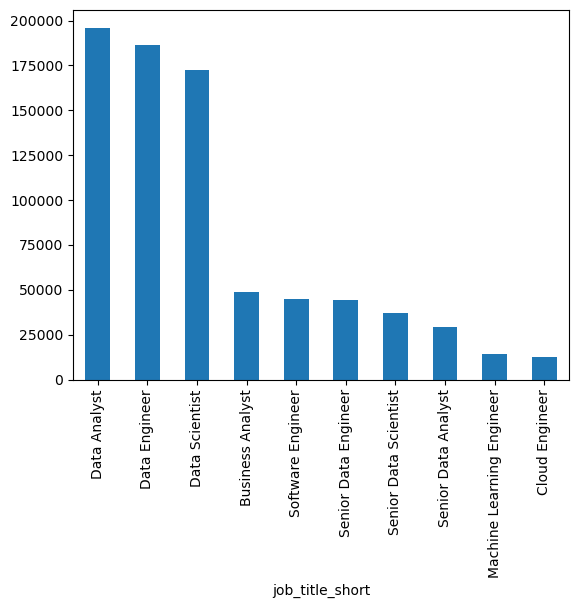

In [2]:
# create a simple subplot
fig, ax = plt.subplots()

# plot the data
df['job_title_short'].value_counts().plot(kind='bar', ax=ax)
plt.show()

In [3]:
df['job_title_short'].value_counts()

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

In [4]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

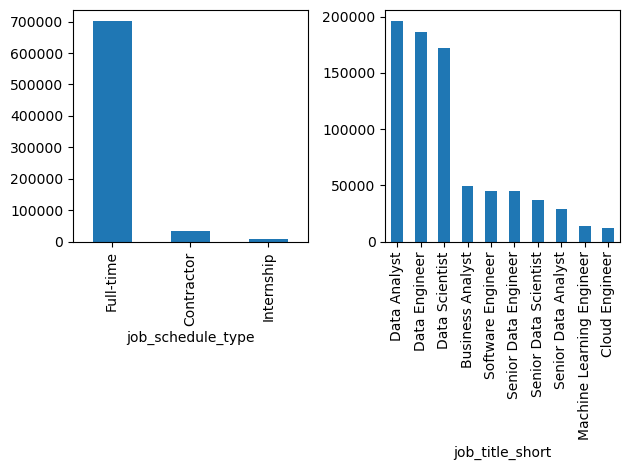

In [12]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar',ax= ax[1])

df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax= ax[0])

fig.tight_layout()

In [6]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [25]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']


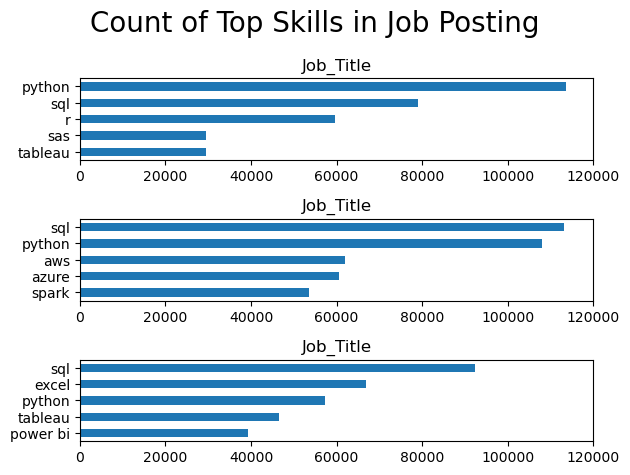

In [50]:
fig, ax = plt.subplots(3, 1)

for  i, job_title in enumerate(job_titles):
      df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
      df_plot.plot(kind='barh',x= 'job_skills', y= 'skill_count', ax= ax[i], title= 'Job_Title')
      ax[i].invert_yaxis()
      ax[i].set_ylabel('')
      ax[i].legend().set_visible(False)
      ax[i].set_xlim(0, 120000)

fig.suptitle('Count of Top Skills in Job Posting', fontsize= 20)
fig.tight_layout()